In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.metrics import log_loss, accuracy_score, mean_squared_error
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
trainDataset = pd.read_csv('/content/drive/MyDrive/Fashion-MNIST/fashion-mnist_train.csv')
testDataset = pd.read_csv('/content/drive/MyDrive/Fashion-MNIST/fashion-mnist_test.csv')
valDataset = pd.read_csv('/content/drive/MyDrive/Fashion-MNIST/fashion-mnist_test.csv')

trainDataset = trainDataset[:8000]
testDataset = testDataset[:2000]
valDataset = valDataset[2000:4000]

print("Training Dataset Shape:", trainDataset.shape)
print()
print(trainDataset.head())
print()
print("Test Dataset Shape:", testDataset.shape)
print()
print(testDataset.head())
print()
print("Validation Dataset Shape:", valDataset.shape)
print()
print(valDataset.head())

Training Dataset Shape: (8000, 785)

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixe

In [ ]:
print(trainDataset.isnull().sum())
print(testDataset.isnull().sum())
print(valDataset.isnull().sum())

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64
label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64
label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64


In [ ]:
# normalizing the pixel values in the Fashion-MNIST dataset to the range [0, 1] for better convergence
trainDataset[trainDataset.columns[1:]] = trainDataset[trainDataset.columns[1:]].astype('float64') / 255.0
testDataset[testDataset.columns[1:]] = testDataset[testDataset.columns[1:]].astype('float64') / 255.0
valDataset[valDataset.columns[1:]] = valDataset[valDataset.columns[1:]].astype('float64') / 255.0

print()
print(trainDataset.head())
print()
print(testDataset.head())
print()
print(valDataset.head())


   label  pixel1  pixel2  pixel3    pixel4    pixel5  pixel6  pixel7  \
0      2     0.0     0.0     0.0  0.000000  0.000000     0.0     0.0   
1      9     0.0     0.0     0.0  0.000000  0.000000     0.0     0.0   
2      6     0.0     0.0     0.0  0.000000  0.000000     0.0     0.0   
3      0     0.0     0.0     0.0  0.003922  0.007843     0.0     0.0   
4      3     0.0     0.0     0.0  0.000000  0.000000     0.0     0.0   

     pixel8  pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  \
0  0.000000     0.0  ...  0.000000       0.0       0.0  0.000000  0.000000   
1  0.000000     0.0  ...  0.000000       0.0       0.0  0.000000  0.000000   
2  0.019608     0.0  ...  0.000000       0.0       0.0  0.117647  0.168627   
3  0.000000     0.0  ...  0.011765       0.0       0.0  0.000000  0.000000   
4  0.000000     0.0  ...  0.000000       0.0       0.0  0.000000  0.000000   

   pixel780  pixel781  pixel782  pixel783  pixel784  
0  0.000000       0.0       0.0       0.0  

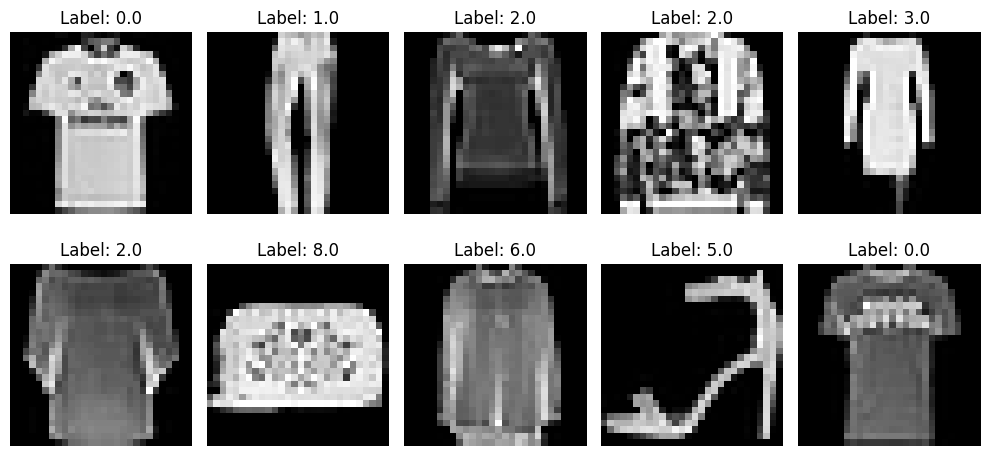

In [ ]:
plt.figure(figsize = (10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(testDataset.values[i, 1:].reshape(28, 28), cmap = 'gray')
    plt.title("Label: " + str(testDataset.values[i, 0]))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
X_train = trainDataset[trainDataset.columns[1:]]
Y_train = trainDataset[trainDataset.columns[0]]
X_test = testDataset[testDataset.columns[1:]]
Y_test = testDataset[testDataset.columns[0]]
X_val = valDataset[valDataset.columns[1:]]
Y_val = valDataset[valDataset.columns[0]]

In [ ]:
activationFunctions = ['logistic', 'tanh', 'relu', 'identity']
results = {}

for activationFunction in activationFunctions:
    # set max_iter = 1 to fit 100 times for tracking training and validation loss each epoch (can only calculate training loss without for loop)
    mlpClassifier = MLPClassifier(hidden_layer_sizes = (128, 64, 32), max_iter = 1, solver = 'adam', batch_size = 128, learning_rate_init = 2e-5, activation = activationFunction, random_state = 42, verbose = False, warm_start = True)

    trainingLoss = []
    validationLoss = []

    # ignoring warnings to prevent hundreds of convergence warning messages
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        for epoch in range(100):
            mlpClassifier.fit(X_train, Y_train)

            Y_TrainPredictions = mlpClassifier.predict_proba(X_train)
            trainLoss = log_loss(Y_train, Y_TrainPredictions)
            trainingLoss.append(trainLoss)

            Y_ValPredictions = mlpClassifier.predict_proba(X_val)
            valLoss = log_loss(Y_val, Y_ValPredictions)
            validationLoss.append(valLoss)

    Y_TestPredictions = mlpClassifier.predict_proba(X_test)
    testLoss = log_loss(Y_test, Y_TestPredictions)
    testAccuracy = mlpClassifier.score(X_test, Y_test)

    results[activationFunction] = (trainingLoss, validationLoss, testLoss, testAccuracy)

    print("Reached max_iter for " + activationFunction + " activation function")

Reached max_iter for logistic activation function
Reached max_iter for tanh activation function
Reached max_iter for relu activation function
Reached max_iter for identity activation function


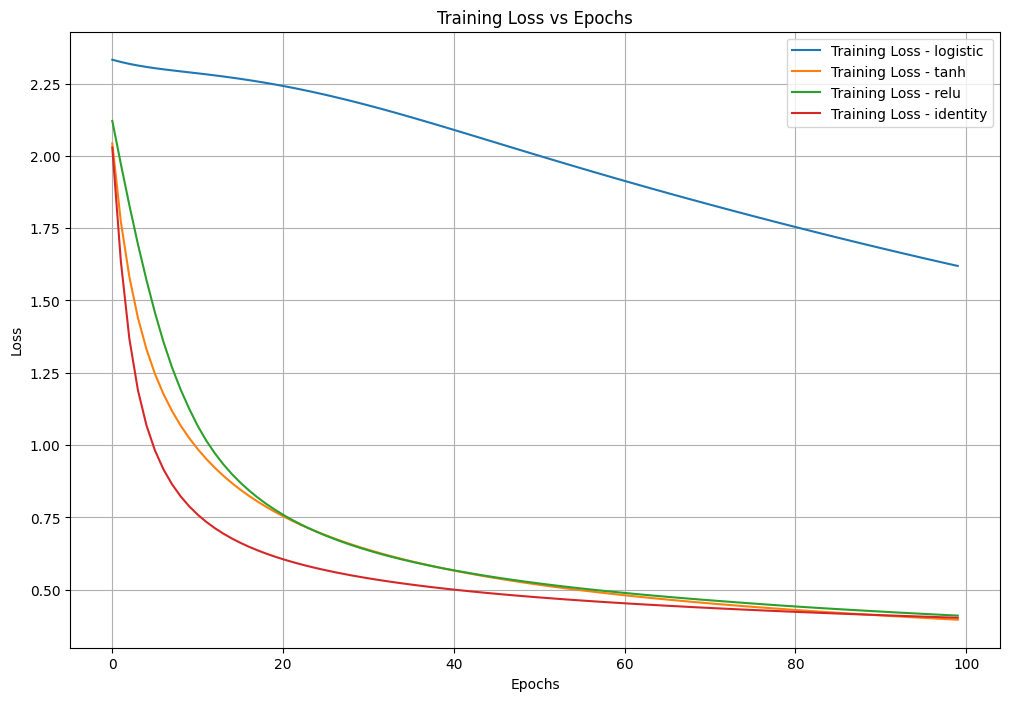

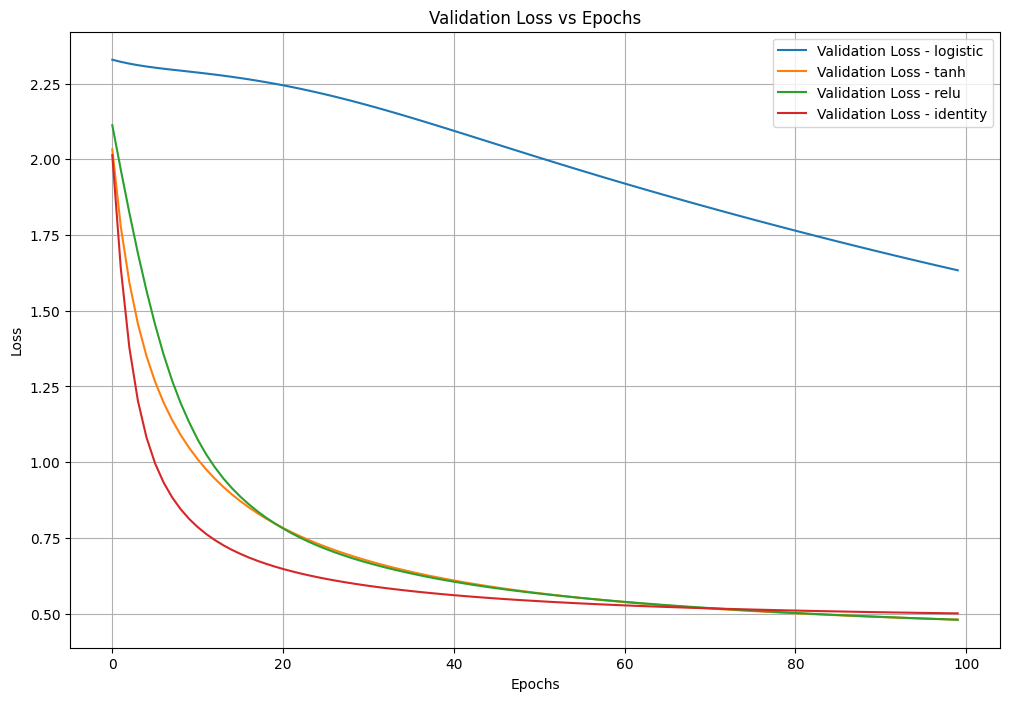


Test Loss for logistic activation function: 1.62324765694004
Test Accuracy for logistic activation function: 0.4405

Test Loss for tanh activation function: 0.4727613033946461
Test Accuracy for tanh activation function: 0.8345

Test Loss for relu activation function: 0.48348738603887526
Test Accuracy for relu activation function: 0.8365

Test Loss for identity activation function: 0.49001333682487136
Test Accuracy for identity activation function: 0.828



In [ ]:
plt.figure(figsize = (12, 8))
for activationFunction, (trainingLoss, validationLoss, testLoss, testAccuracy) in results.items():
    plt.plot(trainingLoss, label = 'Training Loss - ' + activationFunction)

plt.title('Training Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize = (12, 8))
for activationFunction, (trainingLoss, validationLoss, testLoss, testAccuracy) in results.items():
    plt.plot(validationLoss, label = 'Validation Loss - ' + activationFunction)

plt.title('Validation Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

print()
for activationFunction, (trainingLoss, validationLoss, testLoss, testAccuracy) in results.items():
    print("Test Loss for", activationFunction, "activation function:", testLoss)
    print("Test Accuracy for", activationFunction, "activation function:", testAccuracy)
    print()

In [ ]:
bestActivationFunc = 'relu'   # from previous code block's output

mlpClassifier = MLPClassifier(hidden_layer_sizes = (128, 64, 32), activation = bestActivationFunc, max_iter = 100, random_state = 42)

solvers = ['adam', 'sgd', 'lbfgs']
learningRates = [2e-3, 2e-5]
batchSizes = [32, 64]

grid = {'solver': solvers, 'learning_rate_init': learningRates, 'batch_size': batchSizes}

gridSearch = GridSearchCV(estimator = mlpClassifier, param_grid = grid, scoring = 'accuracy', cv = 2, verbose = 2)

gridSearch.fit(X_train, Y_train)

bestParameters = gridSearch.best_params_
bestScore = gridSearch.best_score_

Fitting 2 folds for each of 12 candidates, totalling 24 fits
[CV] END batch_size=32, learning_rate_init=0.002, solver=adam; total time=  46.9s
[CV] END batch_size=32, learning_rate_init=0.002, solver=adam; total time=  52.2s


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END batch_size=32, learning_rate_init=0.002, solver=sgd; total time=  49.8s


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END batch_size=32, learning_rate_init=0.002, solver=sgd; total time=  50.1s


...

[CV] END batch_size=64, learning_rate_init=2e-05, solver=sgd; total time=  32.9s


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END batch_size=64, learning_rate_init=2e-05, solver=lbfgs; total time=  25.0s


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


[CV] END batch_size=64, learning_rate_init=2e-05, solver=lbfgs; total time=  23.1s


In [ ]:
print("Best Hyperparameters from Grid Search:")
print(bestParameters)
print("Best Accuracy: " + str(bestScore))

Best Hyperparameters from Grid Search:
{'batch_size': 64, 'learning_rate_init': 0.002, 'solver': 'adam'}
Best Accuracy: 0.8534999999999999


Number of features: 784
c: 392
b: 196
a: 98



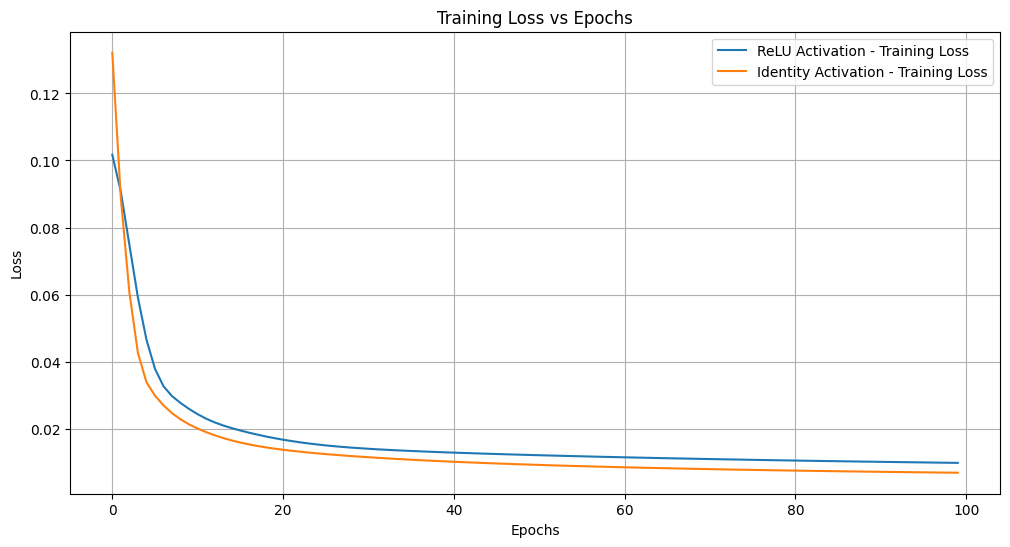

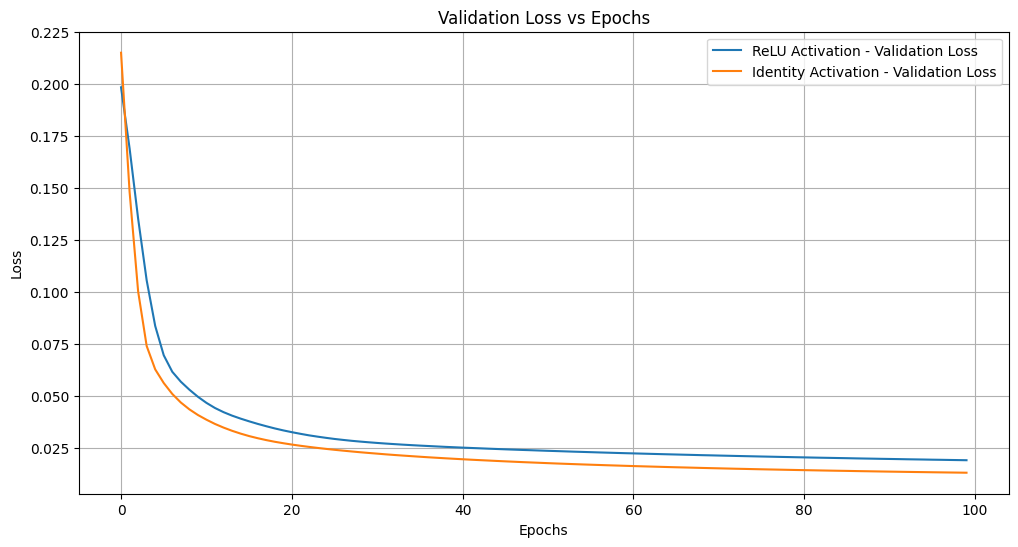


(2000, 784)
(2000, 784)



In [ ]:
X_train = trainDataset.drop(columns = trainDataset.columns[0]).values
X_test = testDataset.drop(columns = testDataset.columns[0]).values

features = X_train.shape[1]
# layer sizes are halved in the former part of the network to gradually reduce dimensionality helping the network learn key features at each stage
# layer sizes are doubled in the latter part of the network to expand and refine the compressed features allowing the model to reconstruct complex patterns for accurate predictions
# kinda like encoder - decoder
c = int(features / 2)
b = int(c / 2)
a = int(b / 2)

print("Number of features:", features)
print("c:", c)
print("b:", b)
print("a:", a)
print()

trainLossReLU = []
valLossReLU = []
trainLossIdentity = []
valLossIdentity = []

# set max_iter = 1 to fit 100 times for tracking training and validation loss each epoch (can only calculate training loss without for loop)
mlpRegressorRELU = MLPRegressor(hidden_layer_sizes = (c, b, a, b, c), activation = 'relu', solver = 'adam', learning_rate_init = 2e-5, max_iter = 1, verbose = False, warm_start = True)

# ignoring warnings to prevent hundreds of convergence warning messages
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for epoch in range(100):
        mlpRegressorRELU.fit(X_train, X_train)
        trainLoss = mlpRegressorRELU.loss_
        trainLossReLU.append(trainLoss)
        valLoss = mean_squared_error(X_val, mlpRegressorRELU.predict(X_val))
        valLossReLU.append(valLoss)

# set max_iter = 1 to fit 100 times for tracking training and validation loss each epoch (can only calculate training loss without for loop)
mlpRegressorIdentity = MLPRegressor(hidden_layer_sizes = (c, b, a, b, c), activation = 'identity', solver = 'adam', learning_rate_init = 2e-5, max_iter = 1, verbose = False, warm_start = True)

# ignoring warnings to prevent hundreds of convergence warning messages
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for epoch in range(100):
        mlpRegressorIdentity.fit(X_train, X_train)
        trainLoss = mlpRegressorIdentity.loss_
        trainLossIdentity.append(trainLoss)
        valLoss = mean_squared_error(X_val, mlpRegressorIdentity.predict(X_val))
        valLossIdentity.append(valLoss)

plt.figure(figsize = (12, 6))
plt.plot(trainLossReLU, label = 'ReLU Activation - Training Loss')
plt.plot(trainLossIdentity, label = 'Identity Activation - Training Loss')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize = (12, 6))
plt.plot(valLossReLU, label = 'ReLU Activation - Validation Loss')
plt.plot(valLossIdentity, label = 'Identity Activation - Validation Loss')
plt.title('Validation Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

testPredictionsRELU = mlpRegressorRELU.predict(X_test)
testPredictionsIdentity = mlpRegressorIdentity.predict(X_test)

print()
print(testPredictionsRELU.shape)
print(testPredictionsIdentity.shape)
print()

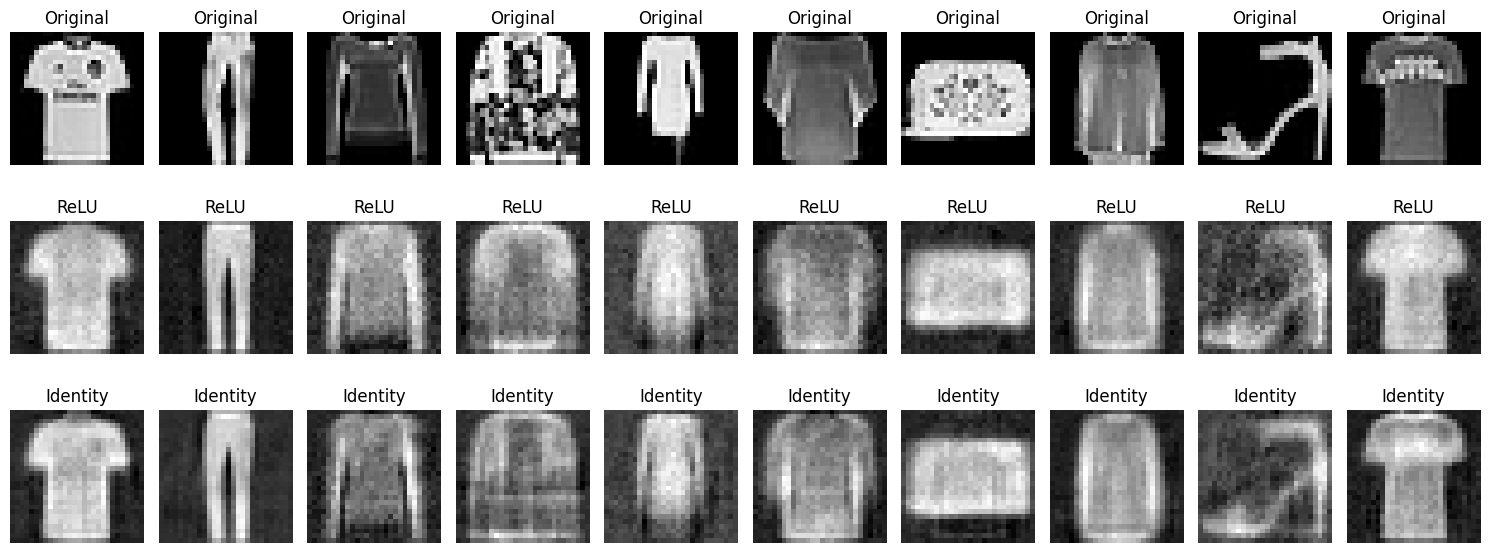

In [ ]:
# reconstructing the images
plt.figure(figsize = (15, 6))
for i in range(10):
    plt.subplot(3, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap = 'gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3, 10, i + 11)
    plt.imshow(testPredictionsRELU[i].reshape(28, 28), cmap = 'gray')
    plt.title("ReLU")
    plt.axis('off')

    plt.subplot(3, 10, i + 21)
    plt.imshow(testPredictionsIdentity[i].reshape(28, 28), cmap = 'gray')
    plt.title("Identity")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# extracting weights and biases from the trained model to obtain the output of the third hidden layer (feature vector of size a)
def extractA_features(regressor, X):
    firstHiddenLayerOutput = np.maximum(0, np.dot(X, regressor.coefs_[0]) + regressor.intercepts_[0])
    secondHiddenLayerOutput = np.maximum(0, np.dot(firstHiddenLayerOutput, regressor.coefs_[1]) + regressor.intercepts_[1])
    thirdHiddenLayerOutput = np.maximum(0, np.dot(secondHiddenLayerOutput, regressor.coefs_[2]) + regressor.intercepts_[2])
    aFeatures = thirdHiddenLayerOutput
    return aFeatures

trainFeaturesReLU = extractA_features(mlpRegressorRELU, X_train)
trainFeaturesIdentity = extractA_features(mlpRegressorIdentity, X_train)
testFeaturesReLU = extractA_features(mlpRegressorRELU, X_test)
testFeaturesIdentity = extractA_features(mlpRegressorIdentity, X_test)

print()
print("Train Feature Vector Shape (ReLU):", trainFeaturesReLU.shape)
print("Test Feature Vector Shape (ReLU):", testFeaturesReLU.shape)
print("Train Feature Vector Shape (Identity):", trainFeaturesIdentity.shape)
print("Test Feature Vector Shape (Identity):", testFeaturesIdentity.shape)


Train Feature Vector Shape (ReLU): (8000, 98)
Test Feature Vector Shape (ReLU): (2000, 98)
Train Feature Vector Shape (Identity): (8000, 98)
Test Feature Vector Shape (Identity): (2000, 98)


In [ ]:
mlpClassifierReLU = MLPClassifier(hidden_layer_sizes = (a, a), activation = 'relu', solver = 'adam', learning_rate_init = 2e-5, max_iter = 200, random_state = 42, verbose = False)
mlpClassifierReLU.fit(trainFeaturesReLU, Y_train)

mlpClassifierIdentity = MLPClassifier(hidden_layer_sizes = (a, a), activation = 'identity', solver = 'adam', learning_rate_init = 2e-5, max_iter = 200, random_state = 42, verbose = False)
mlpClassifierIdentity.fit(trainFeaturesIdentity, Y_train)

YTestPredReLU = mlpClassifierReLU.predict(testFeaturesReLU)
YTestPredIdentity = mlpClassifierIdentity.predict(testFeaturesIdentity)

accuracyReLU = accuracy_score(Y_test, YTestPredReLU)
accuracyIdentity = accuracy_score(Y_test, YTestPredIdentity)

print()
print("Accuracy of ReLU Activation Classifier:", accuracyReLU)
print("Accuracy of Identity Activation Classifier:", accuracyIdentity)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



Accuracy of ReLU Activation Classifier: 0.789
Accuracy of Identity Activation Classifier: 0.7825


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
